# Path Patching

**Standard activation patching** tests whether a component is important by replacing its *entire output*. But this conflates all the different roles a component might play. Head H writes a vector to the residual stream, and that vector is read by every downstream head and MLP. Head `H` might send critical information to head `K` (say, the identity of a duplicated name) while simultaneously sending irrelevant information to head `J` (say, positional encoding noise). Standard activation patching cannot distinguish these pathways - it can only tell you that `H` matters overall, not where its output is consumed.

**Path patching** asks a more targeted question: is the specific connection from `H` to `K` important? Instead of replacing H's entire output in the residual stream, path patching replaces *only the component* of `H`'s output that flows into a specific downstream consumer `K`.

The conceptual shift is from **nodes** to **edges** in the computational graph:

- **Activation patching tests nodes:** "Is component `H` important?"
- **Path patching tests edges:** "Is the connection `H→K` important?"

# ACDC - Automated Circuit DisCovery

ACDC starts with the full computational graph of the model, treating every possible edge between components as a candidate connection. It then iteratively tests each edge using path patching: if removing an edge has negligible effect on model behavior for the task, that edge is pruned. After testing all edges, what remains is the circuit - the **minimal subgraph** that accounts for the model's behavior.

The algorithm proceeds in topological order, working **backward from the output**:

1. Start with all edges in the computational graph
2. For each edge (in reverse topological order), temporarily remove it
3. If the model's behavior on the task is unchanged, permanently prune the edge
4. If behavior degrades, keep the edge
5. The surviving edges define the circuit

The threshold for "unchanged" is a tunable parameter, creating a tradeoff between faithfulness (keeping all edges that matter) and minimality (removing as many as possible). A strict threshold keeps more edges and produces a more faithful but less interpretable circuit. A loose threshold prunes aggressively and produces a more minimal but potentially less faithful circuit.

# Combining the Tools

Attribution patching and path patching are not alternatives to activation patching - they extend it. A typical circuit discovery workflow uses all three tools at different stages:

1. Attribution patching for broad screening. Sweep the entire model to identify which components show the largest estimated patching effects. This narrows the search from thousands of components to a manageable set of candidates.
2. Activation patching for confirmation. Run full patching on the top candidates to verify that the gradient approximation was accurate. This catches components where the linear approximation was misleading.
3. Path patching for mechanistic understanding. Once the key components are identified, trace the connections between them. This reveals not just which components participate in the circuit but how information flows between them.

The progression moves from "something is happening at layer 9" (attribution patching) to "head 9.9 is causally important" (activation patching) to "head 9.9 receives S-Inhibition information through its queries and copies name identity through its OV circuit to the output logits" (path patching). Each step adds resolution and mechanistic detail.

In [1]:
from nnsight import VisionLanguageModel
from PIL import Image
import json
import os
from pathlib import Path
import torch
import numpy as np
import gc
from transformers import BitsAndBytesConfig, LlavaForConditionalGeneration, AutoProcessor
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import einops
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected+notebook"

In [2]:
NB_DIR = Path(os.getcwd())  # patching/
PROJECT_DIR = NB_DIR.parent

MODEL_ID = "llava-hf/llava-1.5-7b-hf"
POPE_FILE = PROJECT_DIR / "pope_train" / "coco_train_pope_adversarial.jsonl"
IMAGE_ROOT = PROJECT_DIR / "data" / "coco2014" / "train2014" / "train2014"

NUM_HEADS = 32
NUM_LAYERS = 32
HIDDEN_DIM = 4096
HEAD_DIM = HIDDEN_DIM // NUM_HEADS  # 128

In [3]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,                        # Enable 4-bit quantization
    bnb_4bit_quant_type="nf4",                # Use Normalized Float 4 (best for LLMs)
    bnb_4bit_compute_dtype=torch.float16,     # Compute using float16 for speed (can also use bf16)
    bnb_4bit_use_double_quant=True            # Quantize the quantization constants to save more memory
)

model = VisionLanguageModel(
    "llava-hf/llava-1.5-7b-hf",
    device_map="cuda",
    dispatch=True,
    # quantization_config=quantization_config
)
processor = AutoProcessor.from_pretrained(MODEL_ID)
tokenizer = processor.tokenizer

lm = model.model.language_model
print(f"Model loaded on {model.device}")
print(f"Language model layers: {len(lm.layers)}")
print(f"Hidden dim: {lm.config.hidden_size}")
print(f"Num attention heads: {lm.config.num_attention_heads}")

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded on cuda:0
Language model layers: 32
Hidden dim: 4096
Num attention heads: 32


In [4]:
# Get token IDs for "Yes" and "No" — used for probability difference p(Yes) - p(No)
yes_id = tokenizer.encode("Yes", add_special_tokens=False)[0]
no_id = tokenizer.encode("No", add_special_tokens=False)[0]
print(f"'Yes' token id: {yes_id}, '{tokenizer.decode([yes_id])}'")
print(f"'No'  token id: {no_id}, '{tokenizer.decode([no_id])}'")

'Yes' token id: 3869, 'Yes'
'No'  token id: 1939, 'No'


## 0. Helpers

In [5]:
def build_prompt(question_text: str) -> str:
    """Build the LLaVA prompt exactly as in the POPE data — no extra instructions."""
    return (
        f"USER: <image>\n{question_text}\nASSISTANT:"
    )

def get_prob_diff(logits):
    """Extract p(Yes) - p(No) from model outputs using softmax over the vocabulary.
    Positive → model prefers Yes. Negative → model prefers No."""
    logits = logits[0, -1, :]  # last token position
    probs = torch.softmax(logits.float(), dim=-1)
    return probs[yes_id].item() - probs[no_id]

def add_gaussian_noise(image: Image.Image, mean: float = 0.0, std: float = 25.5) -> Image.Image:
    """
    Adds Gaussian noise to a PIL Image.
    """
    # Convert image to numpy array (float32 to prevent overflow during addition)
    img_array = np.array(image).astype(np.float32)
    
    # Generate Gaussian noise
    noise = np.random.normal(mean, std, img_array.shape)
    
    # Add noise, clip to valid pixel range [0, 255], and convert back to uint8
    noisy_img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)
    
    return Image.fromarray(noisy_img_array)

def prepare_inputs(prompt: str, image, processor, noise_std, device):
    """
    Prepares clean and corrupted inputs for LLaVA 1.5.
    """
    # 1. Create the corrupted version of the image
    corrupted_image = add_gaussian_noise(image, std=noise_std)
    
    # 2. Process the clean inputs
    clean_inputs = processor(
        text=prompt, 
        images=image, 
        return_tensors="pt"
    ).to(device)
    
    # 3. Process the corrupted inputs
    corrupted_inputs = processor(
        text=prompt, 
        images=corrupted_image, 
        return_tensors="pt"
    ).to(device)
    
    return clean_inputs, corrupted_inputs

def plot_heatmap(effects, baseline_pd, title, vmin=None, vmax=None):
    """Plot a single 32×32 heatmap of attribution scores (gradient × activation)."""
    if vmin is None:
        vmax_abs = max(abs(effects.min()), abs(effects.max()))
        vmin, vmax = -vmax_abs, vmax_abs

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    sns.heatmap(
        effects,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=range(0, 32),
        yticklabels=range(0, 32),
        cbar_kws={"label": "Attribution Score  ∇[p(Yes)−p(No)] · activation  (grad × act)", "shrink": 0.8},
        linewidths=0.0,
    )
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_title(f"{title}\n(baseline p(Yes)−p(No) = {baseline_pd:.4f})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


In [6]:
# Load existing model answers and join with labels to classify TP/TN/FP
ANS_FILE = PROJECT_DIR / "results" / "train" / "llava15_7b_adversarial_train.jsonl"
LABEL_FILE = PROJECT_DIR / "pope_train" / "coco_train_pope_adversarial.jsonl"

answers = []
with open(ANS_FILE) as f:
    for line in f:
        if line.strip():
            answers.append(json.loads(line))

labels = []
with open(LABEL_FILE) as f:
    for line in f:
        if line.strip():
            labels.append(json.loads(line))

# Index labels by question_id
label_by_qid = {l["question_id"]: l for l in labels}

results = []
for ans in answers:
    qid = ans["question_id"]
    lab = label_by_qid.get(qid)
    if lab is None:
        continue
    pred = ans["answer"]
    results.append((lab, pred, None))

print(f"Loaded {len(results)} matched (answer + label) pairs")

Loaded 10002 matched (answer + label) pairs


In [7]:
# Classify into TP, TN, FP, FN using saved answers (no logit_diff yet)
tp = [(item, None) for item, pred, _ in results if item["label"] == "yes" and pred == "yes"]
tn = [(item, None) for item, pred, _ in results if item["label"] == "no"  and pred == "no"]
fp = [(item, None) for item, pred, _ in results if item["label"] == "no"  and pred == "yes"]
fn = [(item, None) for item, pred, _ in results if item["label"] == "yes" and pred == "no"]

print(f"TP: {len(tp)} | TN: {len(tn)} | FP: {len(fp)} | FN: {len(fn)}")

# Pick one representative of each type
tp_example, _ = tp[0]
tn_example, _ = tn[0]
fp_example, _ = fp[0]

print(f"\nTP example: {tp_example['text'][:80]} (label={tp_example['label']})")
print(f"TN example: {tn_example['text'][:80]} (label={tn_example['label']})")
print(f"FP example: {fp_example['text'][:80]} (label={fp_example['label']})")

TP: 4654 | TN: 3333 | FP: 1668 | FN: 347

TP example: Is there a bottle in the image? (label=yes)
TN example: Is there a car in the image? (label=no)
FP example: Is there a bowl in the image? (label=no)


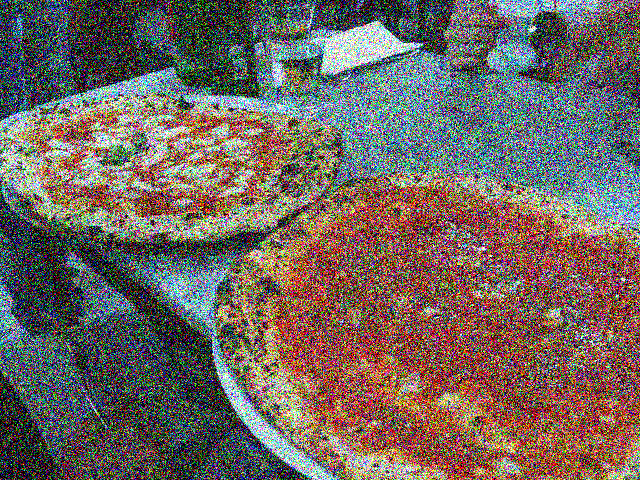

In [8]:
tp_img = Image.open(IMAGE_ROOT / tp_example["image"]).convert("RGB")
noised_tp_img = add_gaussian_noise(tp_img, std=100)

noised_tp_img

## 1. Attribution Patching

The core insight of attribution patching is that we can approximate the effect of patching each component without actually performing the patch. The idea relies on a first-order Taylor approximation: if we know how sensitive the output metric is to changes at each activation (the gradient), and we know how much each activation changes between clean and corrupted runs (the activation difference), we can estimate the patching effect as their product.¹

Formally, the estimated patching effect for activation $a_i$ is:

$$\text{Patch effect of } a_i \approx \nabla_{a_i}\mathcal{L} \cdot (a_i^{\text{clean}} - a_i^{\text{corrupt}})$$

The gradient $\nabla_{a_i}\mathcal{L}$ captures the local sensitivity of the metric to perturbations at $a_i$. The difference $(a_i^{\text{clean}} - a_i^{\text{corrupt}})$ captures how much the activation actually changes between the two runs. Their dot product estimates how much the metric would change if we replaced the corrupted activation with the clean one at that location.

The efficiency gain is dramatic. Full activation patching requires $O(n)$ forward passes, where $n$ is the number of components. Attribution patching requires exactly two forward passes (one clean, one corrupted) plus one backward pass (to compute gradients). That is three passes total, regardless of model size. For GPT-3 with 4.7 million neurons, this means 3 passes instead of 4.7 million.

In [9]:
def attribution_patching(model, clean_inputs, corrupted_inputs):
    clean_out = []
    corrupted_out = []
    corrupted_grads = []

    # Pass 1  clean run.
    with model.trace(**clean_inputs):
        for layer in model.model.language_model.layers:
            # Clean attention output for this layer, across all heads
            attn_out = layer.self_attn.o_proj.input
            clean_out.append(attn_out.save())

        clean_outputs = model.lm_head.output
        baseline_prob_diff = get_prob_diff(clean_outputs.cpu()).save()

    # Pass 2 corrupted run + backward.
    with model.trace(**corrupted_inputs):
        corrupted_refs = []
        for layer in model.model.language_model.layers:
            # Corrupted attention output for this layer, across all heads
            attn_out = layer.self_attn.o_proj.input  # last token position
            attn_out.requires_grad_(True)        # non-leaf tensor needs this for a grad
            corrupted_refs.append(attn_out)
            corrupted_out.append(attn_out.save())

        corrupted_outputs = model.lm_head.output

        value = get_prob_diff(corrupted_outputs.cpu())

        with value.backward():
            for attn_out in reversed(corrupted_refs):
                corrupted_grads.insert(0, attn_out.grad.save())

    patching_results = []

    for corrupted_grad, corrupted, clean, layer in zip(
        corrupted_grads, corrupted_out, clean_out, range(len(clean_out))
    ):

        residual_attr = einops.reduce(
            corrupted_grad[:, -1, :] * (clean[:, -1, :] - corrupted[:, -1, :]),  # grad × (clean - corrupted)
            "batch (head dim) -> head",
            "sum",
            head = 32,
            dim = 128,
        )

        patching_results.append(
            residual_attr.detach().cpu().numpy()
        )

    torch.cuda.empty_cache()

    return baseline_prob_diff, patching_results

In [10]:
def print_top_heads(effects, label, n=12):
    """Print the top-N most influential heads (by absolute effect)."""
    flat = [(effects[l, h], l, h) for l in range(NUM_LAYERS) for h in range(NUM_HEADS)]
    flat.sort(key=lambda x: -abs(x[0]))
    print(f"\n{label} — top {n} most influential heads:")
    for i, (val, l, h) in enumerate(flat[:n]):
        direction = "promotes pred" if val > 0 else "suppresses pred"
        print(f"  {i+1}. L{l:02d}H{h:02d}  indirect_effect={val:+.3f}  ({direction})")
    return [(l, h) for _, l, h in flat[:n]]

In [11]:
N_SAMPLES = 200

# Pick N_SAMPLES from each category (skip if not enough)
import random
random.seed(42)

tp_samples = random.sample(tp, min(N_SAMPLES, len(tp)))
tn_samples = random.sample(tn, min(N_SAMPLES, len(tn)))
fp_samples = random.sample(fp, min(N_SAMPLES, len(fp)))
fn_samples = random.sample(fn, min(N_SAMPLES, len(fn)))

print(f"Selected {len(tp_samples)} TP, {len(tn_samples)} TN, {len(fp_samples)} FP")

def attribution_patching_multi(samples, label, model, processor, noise_std=100):
    """
    Run attribution patching on multiple samples and return the results.
    """
    baselines = []
    all_effects = np.zeros((len(samples), NUM_LAYERS, NUM_HEADS))

    for idx, (item, _) in enumerate(tqdm(samples, desc=f"Attributing {label}")):
        clean_inputs, corrupted_inputs = prepare_inputs(
            build_prompt(item["text"]),
            Image.open(IMAGE_ROOT / item["image"]).convert("RGB"),
            processor,
            noise_std,
            model.device
        )
        baseline_pd, effects = attribution_patching(model, clean_inputs, corrupted_inputs)

        baselines.append(baseline_pd.detach().cpu().numpy())
        all_effects[idx] = np.array(effects)

    return baselines, all_effects


Selected 200 TP, 200 TN, 200 FP


In [12]:
tp_baselines, tp_all_effects = attribution_patching_multi(tp_samples, "TP", model, processor)
tn_baselines, tn_all_effects = attribution_patching_multi(tn_samples, "TN", model, processor)
fp_baselines, fp_all_effects = attribution_patching_multi(fp_samples, "FP", model, processor)
fn_baselines, fn_all_effects = attribution_patching_multi(fn_samples, "FN", model, processor)

Attributing FN: 100%|██████████| 200/200 [03:07<00:00,  1.07it/s]


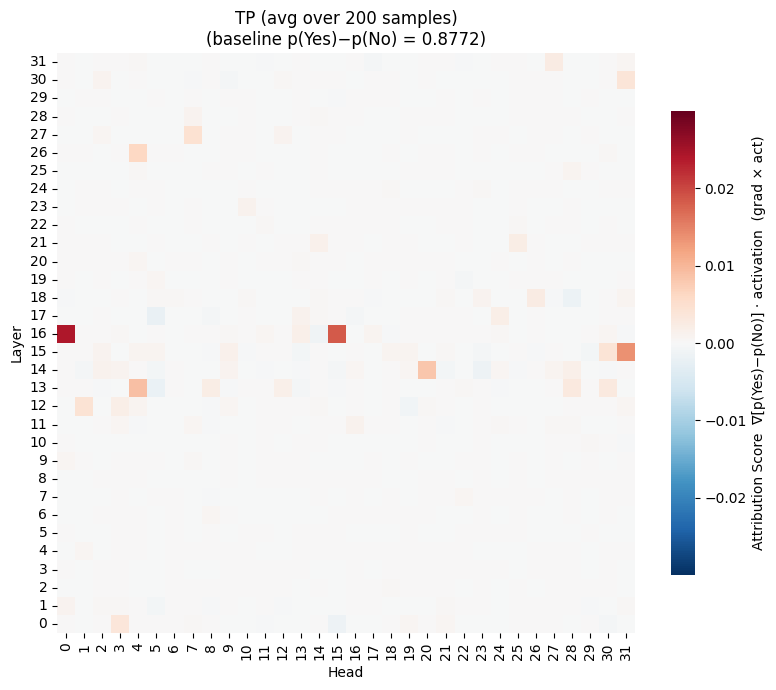

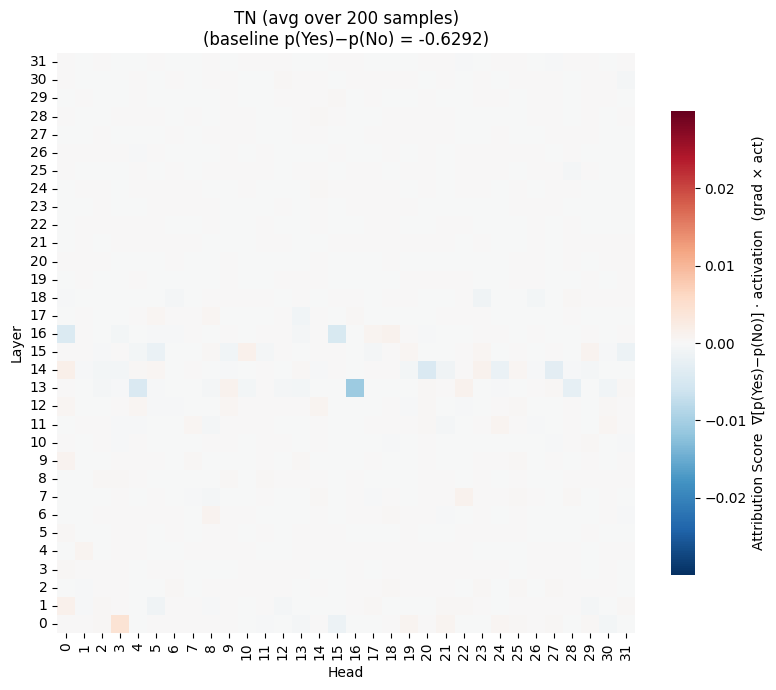

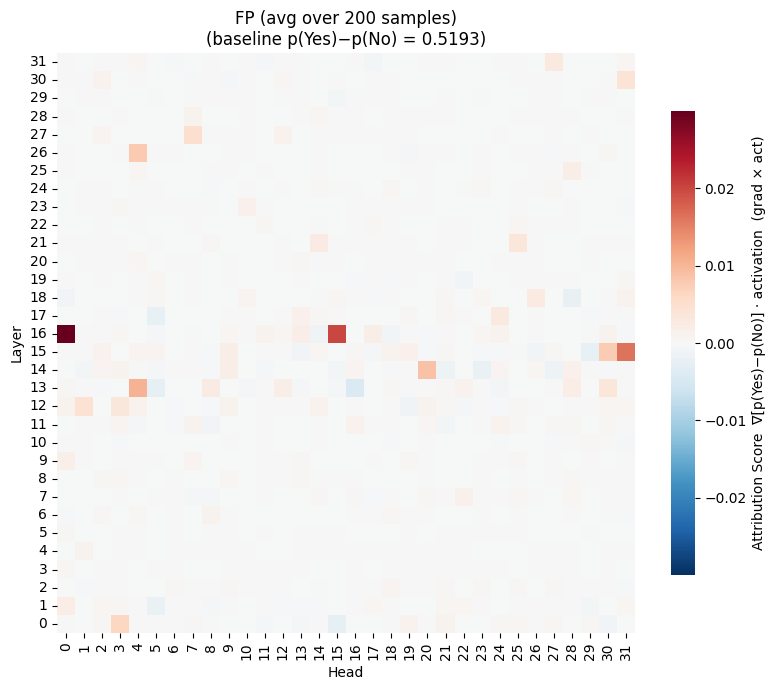

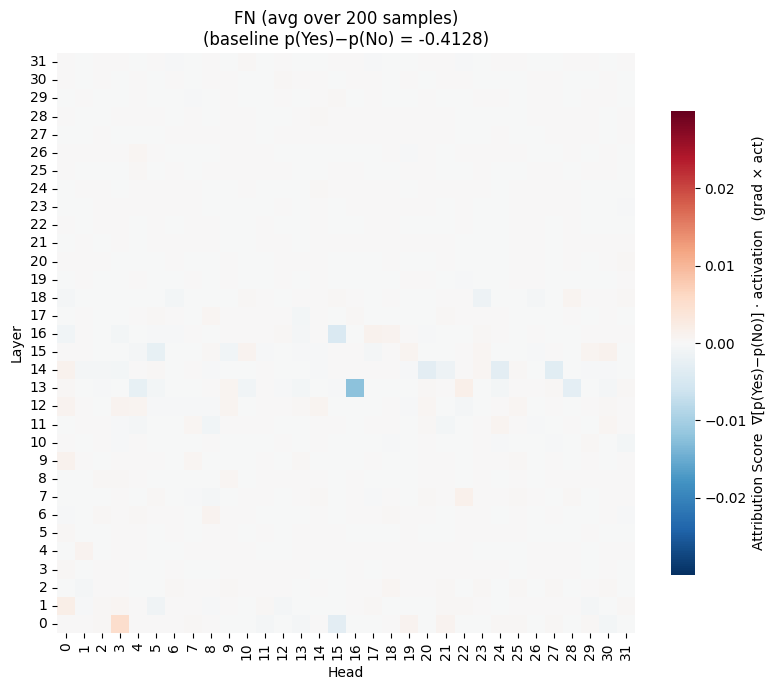

In [13]:
tp_mean = tp_all_effects.mean(axis=0)
tn_mean = tn_all_effects.mean(axis=0)
fp_mean = fp_all_effects.mean(axis=0)
fn_mean = fn_all_effects.mean(axis=0)

tp_mean_baseline = np.mean(tp_baselines)
tn_mean_baseline = np.mean(tn_baselines)
fp_mean_baseline = np.mean(fp_baselines)
fn_mean_baseline = np.mean(fn_baselines)

# Consistent colour scale across all three
all_mean = np.stack([tp_mean, tn_mean, fp_mean, fn_mean])
vmax_abs = max(abs(all_mean.min()), abs(all_mean.max()))
vmin, vmax = -vmax_abs, vmax_abs

plot_heatmap(tp_mean, tp_mean_baseline,
             f"TP (avg over {len(tp_samples)} samples)", vmin, vmax)
plot_heatmap(tn_mean, tn_mean_baseline,
             f"TN (avg over {len(tn_samples)} samples)", vmin, vmax)
plot_heatmap(fp_mean, fp_mean_baseline,
             f"FP (avg over {len(fp_samples)} samples)", vmin, vmax)
plot_heatmap(fn_mean, fn_mean_baseline,
             f"FN (avg over {len(fn_samples)} samples)", vmin, vmax)

In [14]:
tp_top_heads = print_top_heads(tp_mean, "TP", n=15)
fp_top_heads = print_top_heads(fp_mean, "FP", n=15)
tn_top_heads = print_top_heads(tn_mean, "TN", n=15)
fn_top_heads = print_top_heads(fn_mean, "FN", n=15)

print("TP top heads", tp_top_heads)
print("FP top heads", fp_top_heads)
print("TN top heads", tn_top_heads)
print("FN top heads", fn_top_heads)


TP — top 15 most influential heads:
  1. L16H00  indirect_effect=+0.024  (promotes pred)
  2. L16H15  indirect_effect=+0.018  (promotes pred)
  3. L15H31  indirect_effect=+0.014  (promotes pred)
  4. L13H04  indirect_effect=+0.009  (promotes pred)
  5. L14H20  indirect_effect=+0.008  (promotes pred)
  6. L26H04  indirect_effect=+0.006  (promotes pred)
  7. L27H07  indirect_effect=+0.004  (promotes pred)
  8. L12H01  indirect_effect=+0.004  (promotes pred)
  9. L15H30  indirect_effect=+0.004  (promotes pred)
  10. L30H31  indirect_effect=+0.004  (promotes pred)
  11. L00H03  indirect_effect=+0.004  (promotes pred)
  12. L13H30  indirect_effect=+0.003  (promotes pred)
  13. L13H28  indirect_effect=+0.003  (promotes pred)
  14. L31H27  indirect_effect=+0.002  (promotes pred)
  15. L18H26  indirect_effect=+0.002  (promotes pred)

FP — top 15 most influential heads:
  1. L16H00  indirect_effect=+0.030  (promotes pred)
  2. L16H15  indirect_effect=+0.020  (promotes pred)
  3. L15H31  indire

Attribution scores estimate each head's *linear contribution* to the Yes/No decision. Compare the three heatmaps:

| Case | What it shows |
|------|--------------|
| **TP** (true positive) | Which heads push the model toward "yes" when the object IS present? Red heads are providing visual evidence for the object; blue heads may be generic "say no" biases that the positive evidence overcomes. |
| **TN** (true negative) | Which heads drive a correct "no" when the object is absent? Blue heads here push toward "no" — they may encode absence signals. Red heads pushing toward "yes" on a negative example may indicate spurious correlations. |
| **FP** (false positive) | Which heads cause a spurious "yes" when the object is NOT present? Strong red heads here are likely driving a hallucinated or bias-driven answer. These are candidates for *editing* to reduce false positives. |

**Key things to look for:**
- Heads that show up in TP but not FP → genuinely useful for object recognition
- Heads that show up strongly in FP → potential spurious-correlation detectors
- Late-layer heads (layers 20–31) that are important across all three cases → likely involved in answer formatting rather than visual reasoning
- Early/mid-layer heads that differ between cases → likely involved in visual processing

**Note on attribution vs. ablation:** Attribution scores are *linear approximations* — they don't capture nonlinear interactions or saturation effects. A head with near-zero attribution may still matter if its effect is highly nonlinear. For exact causal effects, use activation patching (zero ablation); attribution patching is ~1000× faster and gives a useful first-order picture.

## 2. Activation Patching (Zero Ablate) to Verify 

In [15]:
def activation_patching(model, clean_inputs, corrupted_inputs, layer, head):
    """
    Activation Patching (Clean -> Corrupt):
    Replaces a specific head's clean activation with its activation from a corrupted run.
    """
    start = head * HEAD_DIM
    end = start + HEAD_DIM

    with torch.no_grad():
        # ── 1. Clean run (Extract the clean activation) ──
        with model.trace(**clean_inputs):
            clean_act = model.model.language_model.layers[layer].self_attn.o_proj.input.save()

        # ── 2. Corrupted run (Baseline - Model is noisy/broken) ──
        with model.trace(**corrupted_inputs):
            output = model.lm_head.output
            baseline_pd = get_prob_diff(output.cpu()).save()

        # ── 3. Patched run (Corrupted model, but rescue 1 head with clean data) ──
        with model.trace(**corrupted_inputs):
            proj_input = model.model.language_model.layers[layer].self_attn.o_proj.input
            # Replace the head's noisy slice with the clean slice
            proj_input[:, :, start:end] = clean_act[:, :, start:end]

            output = model.lm_head.output
            patched_pd = get_prob_diff(output.cpu()).save()

    return baseline_pd.detach(), patched_pd.detach()

In [16]:
N_SAMPLES = 50  # smaller N since full activation patching is expensive (~1 min/sample)
import random
random.seed(42)

tp_samples_ab = random.sample(tp, min(N_SAMPLES, len(tp)))
tn_samples_ab = random.sample(tn, min(N_SAMPLES, len(tn)))
fp_samples_ab = random.sample(fp, min(N_SAMPLES, len(fp)))
fn_samples_ab = random.sample(fn, min(N_SAMPLES, len(fn)))

print(f"Selected {len(tp_samples_ab)} TP, {len(tn_samples_ab)} TN, {len(fp_samples_ab)} FP, {len(fn_samples_ab)} FN")

# ---- Multi-sample wrapper for zero-ablation activation patching ----
def activation_patching_multi(samples, label, model, processor, layer, head, noise_std=100):
    """
    Run Clean -> Corrupt activation patching on *multiple* samples.
    
    The causal effect = baseline p(Yes)−p(No) − patched p(Yes)−p(No).
    Positive delta → the clean head was pushing the model toward "yes".
    """
    deltas = []
    baselines = []
    patcheds = []

    for (item, _) in tqdm(samples, desc=f"Patching {label} (L{layer} H{head})"):
        prompt = build_prompt(item["text"])
        image = Image.open(IMAGE_ROOT / item["image"]).convert("RGB")
        
        # Use your helper to generate both clean and noisy inputs
        clean_inputs, corrupted_inputs = prepare_inputs(
            prompt, image, processor, noise_std, model.device
        )

        baseline_pd, patched_pd = activation_patching(
            model, clean_inputs, corrupted_inputs, layer, head
        )

        base_val = baseline_pd.cpu().numpy()
        patch_val = patched_pd.cpu().numpy()
        
        baselines.append(base_val)
        patcheds.append(patch_val)
        deltas.append(patch_val - base_val)

        # Aggressive cleanup
        del clean_inputs, corrupted_inputs, baseline_pd, patched_pd
        gc.collect()
        torch.cuda.empty_cache()

    return np.array(baselines), np.array(patcheds), np.array(deltas)

Selected 50 TP, 50 TN, 50 FP, 50 FN


In [17]:
# # ======================================================================
# # VERIFYING TOP ATTRIBUTION HEADS WITH ACTIVATION PATCHING
# # ======================================================================
# print("=" * 70)
# print("VERIFYING TOP ATTRIBUTION HEADS WITH CLEAN->CORRUPT PATCHING")
# print("=" * 70)

# print("\n" + "=" * 70)
# print("TP TOP HEADS (for comparison — which heads cause true 'yes'?)")
# print("=" * 70)

# tp_results = {}
# for layer, head in tp_top_heads:
#     print(f"\n--- L{layer:02d}H{head:02d} (TP top head) ---")
#     baselines, patcheds, deltas = activation_patching_multi(
#         tp_samples_ab, "TP", model, processor, layer, head
#     )
#     tp_results[(layer, head)] = (baselines, patcheds, deltas)

#     print(f"  Baseline p(Yes)−p(No): {baselines.mean():.4f} ± {baselines.std():.4f}")
#     print(f"  Patched  p(Yes)−p(No): {patcheds.mean():.4f} ± {patcheds.std():.4f}")
#     print(f"  Δ (baseline − patched): {deltas.mean():+.4f}  ← causal effect of head")
#     print(f"  % samples where head promotes 'yes' (Δ > 0): {(deltas > 0).mean()*100:.0f}%")

# print("\n" + "=" * 70)
# print("FP TOP HEADS (for comparison — which heads cause false 'yes'?)")
# print("=" * 70)

# fp_results = {}
# for layer, head in fp_top_heads:
#     print(f"\n--- L{layer:02d}H{head:02d} (FP top head) ---")
#     baselines, patcheds, deltas = activation_patching_multi(
#         fp_samples_ab, "FP", model, processor, layer, head
#     )
#     fp_results[(layer, head)] = (baselines, patcheds, deltas)

#     print(f"  Baseline p(Yes)−p(No): {baselines.mean():.4f} ± {baselines.std():.4f}")
#     print(f"  Patched  p(Yes)−p(No): {patcheds.mean():.4f} ± {patcheds.std():.4f}")
#     print(f"  Δ (baseline − patched): {deltas.mean():+.4f}")
#     print(f"  % samples where head promotes 'yes' (Δ > 0): {(deltas > 0).mean()*100:.0f}%")

# print("\n" + "=" * 70)
# print("TN TOP HEADS (for comparison — which heads cause true 'no'?)")
# print("=" * 70)

# tn_results = {}
# for layer, head in tn_top_heads:
#     print(f"\n--- L{layer:02d}H{head:02d} (TN top head) ---")
#     baselines, patcheds, deltas = activation_patching_multi(
#         tn_samples_ab, "TN", model, processor, layer, head
#     )
#     tn_results[(layer, head)] = (baselines, patcheds, deltas)

#     print(f"  Baseline p(Yes)−p(No): {baselines.mean():.4f} ± {baselines.std():.4f}")
#     print(f"  Patched  p(Yes)−p(No): {patcheds.mean():.4f} ± {patcheds.std():.4f}")
#     print(f"  Δ (baseline − patched): {deltas.mean():+.4f}")
#     print(f"  % samples where head promotes 'yes' (Δ > 0): {(deltas > 0).mean()*100:.0f}%")

In [18]:
def plot_heatmap_2(effects, baseline_pd, title, vmin=None, vmax=None):
    """Plot a single 32×32 heatmap of causal effects (Clean - Ablated)."""
    if vmin is None:
        # Use nanmax to safely calculate max/min while ignoring NaN (untested) values
        vmax_abs = np.nanmax(np.abs(effects))
        vmin, vmax = -vmax_abs, vmax_abs

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    sns.heatmap(
        effects,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=range(0, 32),
        yticklabels=range(0, 32),
        # --- MODIFIED LABEL ---
        cbar_kws={"label": "Causal Effect  Δ[p(Yes)−p(No)]  (Clean - Ablated)", "shrink": 0.8},
        linewidths=0.0,
    )
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_title(f"{title}\n(Avg baseline p(Yes)−p(No) = {baseline_pd:.4f})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

def visualize_verified_heads(results_dict, label):
    """Converts the sparse results dictionary into a 32x32 grid and plots it."""
    if not results_dict:
        print(f"No results to plot for {label}.")
        return

    # 1. Initialize a 32x32 grid with NaNs (so untested heads are ignored in the plot)
    grid = np.full((32, 32), np.nan)
    baselines = []

    # 2. Map the mean delta for each tested head onto the grid
    for (layer, head), (base, abl, deltas) in results_dict.items():
        grid[layer, head] = deltas.mean()
        baselines.append(base.mean())

    # 3. Calculate the overall mean baseline for the title
    mean_baseline = np.mean(baselines)

    # 4. Plot using the modified heatmap function
    plot_heatmap_2(
        effects=grid, 
        baseline_pd=mean_baseline, 
        title=f"Verified Causal Effect: {label} Top Heads"
    )

# ---- Run Visualizations ----
# visualize_verified_heads(tp_results, "True Positives (TP)")
# visualize_verified_heads(fp_results, "False Positives (FP)")
# visualize_verified_heads(tn_results, "True Negatives (TN)")

## 3. Path Patching to Form Circuit

In [ ]:
# ==========================================================================
# EXPERIMENT 1: Head → Head Path Patching (literature-correct, double-patched)
# ==========================================================================
# Algorithm (per edge D→G):
#   Step 1: Cache clean + corrupted o_proj.input for ALL 32 layers.
#   Step 2: Corrupted run.  Patch sender head D → clean.
#            Freeze EVERY OTHER head at EVERY layer → corrupted.
#            Capture receiver head G's o_proj.input slice → G_isolated.
#   Step 3: Clean run.  Patch receiver head G ← G_isolated.  Measure output.
#
# G_isolated = what G computes when ONLY the edge D→G is corrected.
# The output delta in step 3 IS the pure causal effect of D→G.

def path_patch_head_to_head(model, clean_inputs, corrupted_inputs,
                             sender_layer, sender_head,
                             receiver_layer, receiver_head):
    """
    Path-patch edge: sender HEAD → receiver HEAD.
    
    Returns (clean_pd, patched_pd).
    Positive delta (patched − clean) → the edge pushes toward "yes".
    """
    clean_cache = []
    corrupt_cache = []
    
    s_start, s_end = sender_head * HEAD_DIM, (sender_head + 1) * HEAD_DIM
    r_start, r_end = receiver_head * HEAD_DIM, (receiver_head + 1) * HEAD_DIM

    with torch.no_grad():
        # ── Step 1: Cache clean + corrupted o_proj.input for ALL layers ──
        with model.trace(**clean_inputs):
            for l in range(NUM_LAYERS):
                clean_cache.append(
                    model.model.language_model.layers[l].self_attn.o_proj.input.save()
                )
            clean_out = model.lm_head.output
            clean_pd = get_prob_diff(clean_out.cpu()).save()

        with model.trace(**corrupted_inputs):
            for l in range(NUM_LAYERS):
                corrupt_cache.append(
                    model.model.language_model.layers[l].self_attn.o_proj.input.save()
                )

        # ── Step 2: Corrupted run.  D → clean, freeze ALL others → corrupted.
        #            Capture G_isolated. ──
        with model.trace(**corrupted_inputs):
            for l in range(NUM_LAYERS):
                proj_input = model.model.language_model.layers[l].self_attn.o_proj.input
                for h in range(NUM_HEADS):
                    h_start, h_end = h * HEAD_DIM, (h + 1) * HEAD_DIM
                    if l == sender_layer and h == sender_head:
                        proj_input[:, :, h_start:h_end] = clean_cache[l][:, :, h_start:h_end]
                    else:
                        proj_input[:, :, h_start:h_end] = corrupt_cache[l][:, :, h_start:h_end]
                if l == receiver_layer:
                    receiver_full = model.model.language_model.layers[receiver_layer].self_attn.o_proj.input
                    g_isolated = receiver_full[:, :, r_start:r_end].save()

        # ── Step 3: Clean run.  G ← G_isolated.  Measure. ──
        with model.trace(**clean_inputs):
            receiver_full = model.model.language_model.layers[receiver_layer].self_attn.o_proj.input
            receiver_full[:, :, r_start:r_end] = g_isolated

            output = model.lm_head.output
            patched_pd = get_prob_diff(output.cpu()).save()

    return clean_pd.detach(), patched_pd.detach()


# ---- Multi-sample wrapper ----

def path_patch_multi(samples, label, model, processor,
                     sender_layer, sender_head,
                     receiver_layer, receiver_head, noise_std=100):
    """Run path_patch_head_to_head on multiple samples. Returns array of deltas."""
    deltas = []
    for (item, _) in tqdm(samples,
                          desc=f"Edge L{sender_layer:02d}H{sender_head:02d}→L{receiver_layer:02d}H{receiver_head:02d} ({label})",
                          leave=False):
        prompt = build_prompt(item["text"])
        image = Image.open(IMAGE_ROOT / item["image"]).convert("RGB")
        clean_inputs, corrupted_inputs = prepare_inputs(
            prompt, image, processor, noise_std, model.device
        )
        clean_pd, patched_pd = path_patch_head_to_head(
            model, clean_inputs, corrupted_inputs,
            sender_layer, sender_head, receiver_layer, receiver_head
        )
        deltas.append(patched_pd.cpu().item() - clean_pd.cpu().item())

        del clean_inputs, corrupted_inputs, clean_pd, patched_pd
        gc.collect()
        torch.cuda.empty_cache()

    return np.array(deltas)


# ---- Build per-category edge sets ----
# For each category, edges = all (sender, receiver) pairs within that category's
# top-10 heads where sender_layer < receiver_layer.

def build_edges(top_heads):
    """All directed edges within a top-heads list where sender is upstream."""
    return [(sl, sh, rl, rh)
            for sl, sh in top_heads
            for rl, rh in top_heads
            if sl < rl]

tp_edges = build_edges(tp_top_heads)
tn_edges = build_edges(tn_top_heads)
fp_edges = build_edges(fp_top_heads)
fn_edges = build_edges(fn_top_heads)

for name, edges in [("TP", tp_edges), ("TN", tn_edges),
                     ("FP", fp_edges), ("FN", fn_edges)]:
    print(f"{name}: {len(edges)} edges from {len(set((sl,sh) for sl,sh,_,_ in edges))} senders "
          f"→ {len(set((rl,rh) for _,_,rl,rh in edges))} receivers")


# ---- Experiment: for each category, run its edges on its own samples ----

N_PATH = 30
random.seed(42)
samples = {
    "TP": random.sample(tp, min(N_PATH, len(tp))),
    "TN": random.sample(tn, min(N_PATH, len(tn))),
    "FP": random.sample(fp, min(N_PATH, len(fp))),
    "FN": random.sample(fn, min(N_PATH, len(fn))),
}

all_results = {}  # all_results[category][(sl,sh,rl,rh)] = np.array of deltas

for category, edges in [("TP", tp_edges), ("TN", tn_edges),
                          ("FP", fp_edges), ("FN", fn_edges)]:
    print(f"\n{'='*60}")
    print(f"{category} — {len(edges)} edges × {N_PATH} samples")
    print(f"{'='*60}")

    all_results[category] = {}

    for (sl, sh, rl, rh) in edges:
        deltas = path_patch_multi(
            samples[category], category, model, processor, sl, sh, rl, rh
        )
        all_results[category][(sl, sh, rl, rh)] = deltas

        print(f"  L{sl:02d}H{sh:02d} → L{rl:02d}H{rh:02d}  "
              f"mean={deltas.mean():+.4f}  std={deltas.std():.4f}")

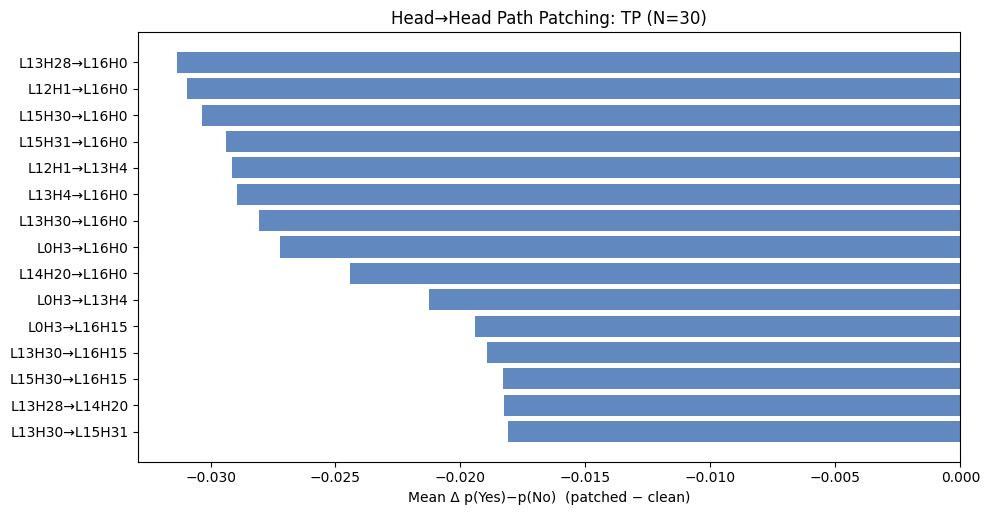

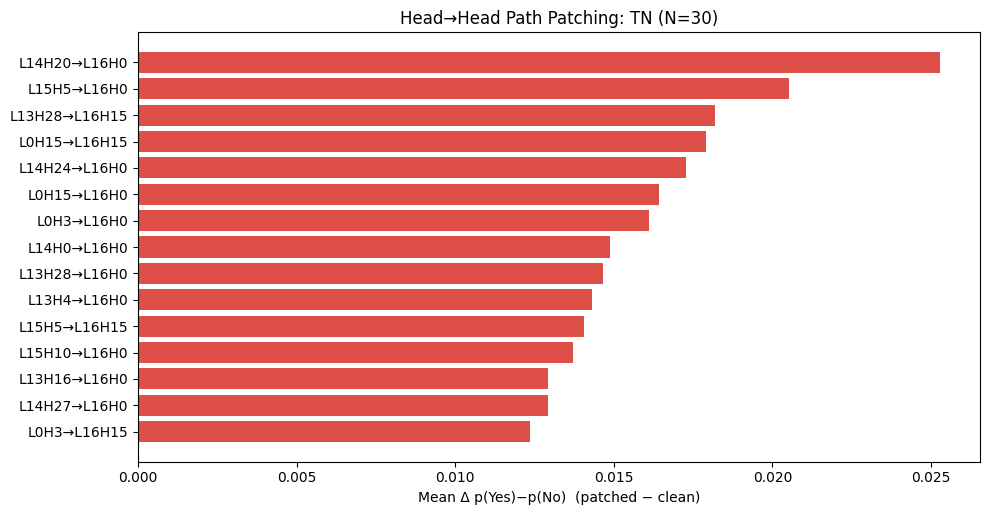

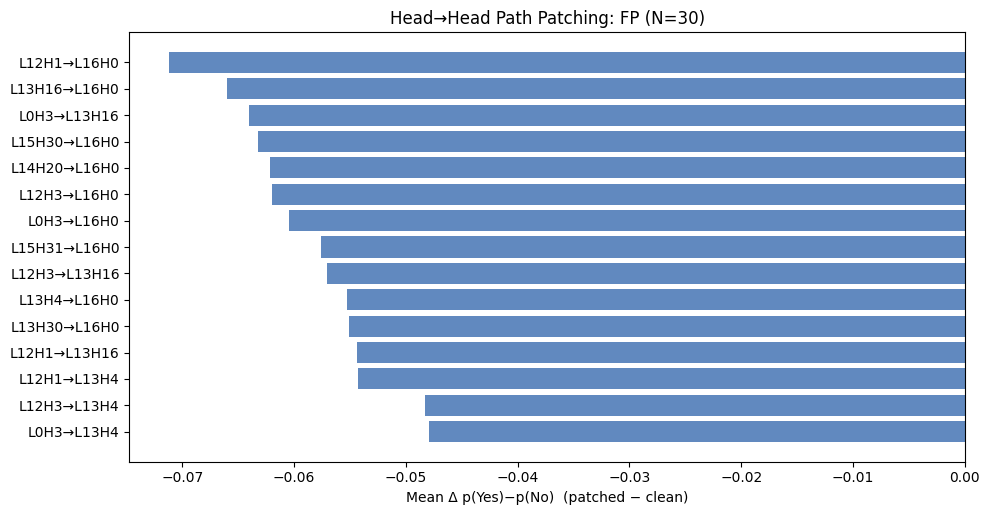

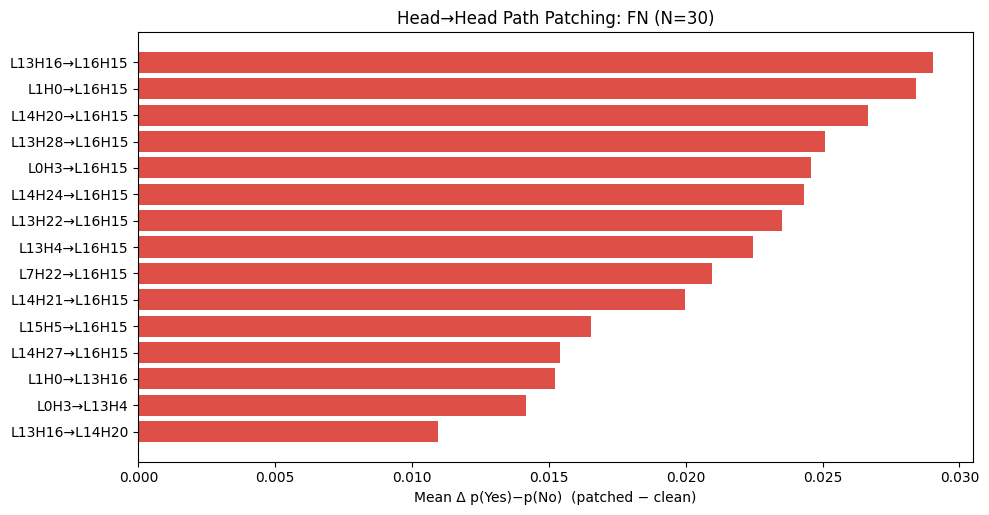


TOP EDGES PER CATEGORY (ranked by |mean delta|)

TP top-5 edges:
  1. L13H28 → L16H00  Δ=-0.0313 (→ no)
  2. L12H01 → L16H00  Δ=-0.0309 (→ no)
  3. L15H30 → L16H00  Δ=-0.0303 (→ no)
  4. L15H31 → L16H00  Δ=-0.0294 (→ no)
  5. L12H01 → L13H04  Δ=-0.0292 (→ no)

TN top-5 edges:
  1. L14H20 → L16H00  Δ=+0.0253 (→ yes)
  2. L15H05 → L16H00  Δ=+0.0205 (→ yes)
  3. L13H28 → L16H15  Δ=+0.0182 (→ yes)
  4. L00H15 → L16H15  Δ=+0.0179 (→ yes)
  5. L14H24 → L16H00  Δ=+0.0173 (→ yes)

FP top-5 edges:
  1. L12H01 → L16H00  Δ=-0.0712 (→ no)
  2. L13H16 → L16H00  Δ=-0.0660 (→ no)
  3. L00H03 → L13H16  Δ=-0.0640 (→ no)
  4. L15H30 → L16H00  Δ=-0.0633 (→ no)
  5. L14H20 → L16H00  Δ=-0.0622 (→ no)

FN top-5 edges:
  1. L13H16 → L16H15  Δ=+0.0290 (→ yes)
  2. L01H00 → L16H15  Δ=+0.0284 (→ yes)
  3. L14H20 → L16H15  Δ=+0.0267 (→ yes)
  4. L13H28 → L16H15  Δ=+0.0251 (→ yes)
  5. L00H03 → L16H15  Δ=+0.0246 (→ yes)


In [20]:
# ---- Visualize head→head path patching (per category) ----

def plot_category_edges(category_results, category, n_show=15):
    """
    Horizontal bar chart of top edges for one category, ranked by |mean delta|.
    """
    items = []
    for (sl, sh, rl, rh), deltas in category_results.items():
        items.append((deltas.mean(), deltas.std(), sl, sh, rl, rh))

    items.sort(key=lambda x: -abs(x[0]))
    items = items[:n_show]

    names = [f"L{sl}H{sh}→L{rl}H{rh}" for _, _, sl, sh, rl, rh in items]
    values = [v for v, _, _, _, _, _ in items]

    fig, ax = plt.subplots(figsize=(10, max(4, len(items) * 0.35)))
    colors = ['#d73027' if v > 0 else '#4575b4' for v in values]
    ax.barh(range(len(items)), values, color=colors, edgecolor='none', alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_yticks(range(len(items)))
    ax.set_yticklabels(names)
    ax.set_xlabel("Mean Δ p(Yes)−p(No)  (patched − clean)")
    ax.set_title(f"Head→Head Path Patching: {category} (N={N_PATH})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


# Plot each category separately
for category in ["TP", "TN", "FP", "FN"]:
    if category in all_results and all_results[category]:
        plot_category_edges(all_results[category], category)


# ---- Cross-category comparison: same edges, different labels ----
# For each category, pick its top-3 strongest edges and show their means.

print("\n" + "=" * 60)
print("TOP EDGES PER CATEGORY (ranked by |mean delta|)")
print("=" * 60)

for category in ["TP", "TN", "FP", "FN"]:
    if category not in all_results:
        continue
    items = [(deltas.mean(), sl, sh, rl, rh)
             for (sl, sh, rl, rh), deltas in all_results[category].items()]
    items.sort(key=lambda x: -abs(x[0]))

    print(f"\n{category} top-5 edges:")
    for i, (mean_val, sl, sh, rl, rh) in enumerate(items[:5]):
        direction = "→ yes" if mean_val > 0 else "→ no"
        print(f"  {i+1}. L{sl:02d}H{sh:02d} → L{rl:02d}H{rh:02d}  "
              f"Δ={mean_val:+.4f} ({direction})")

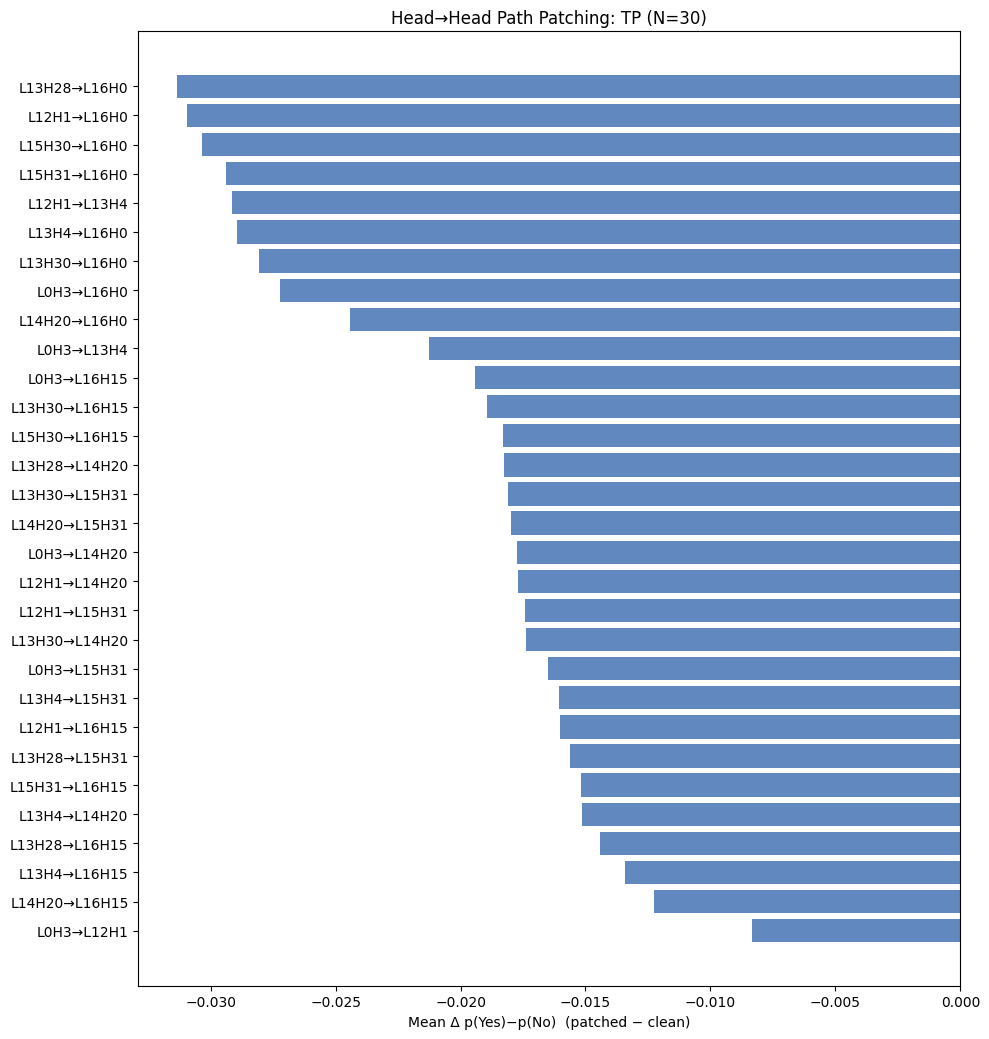

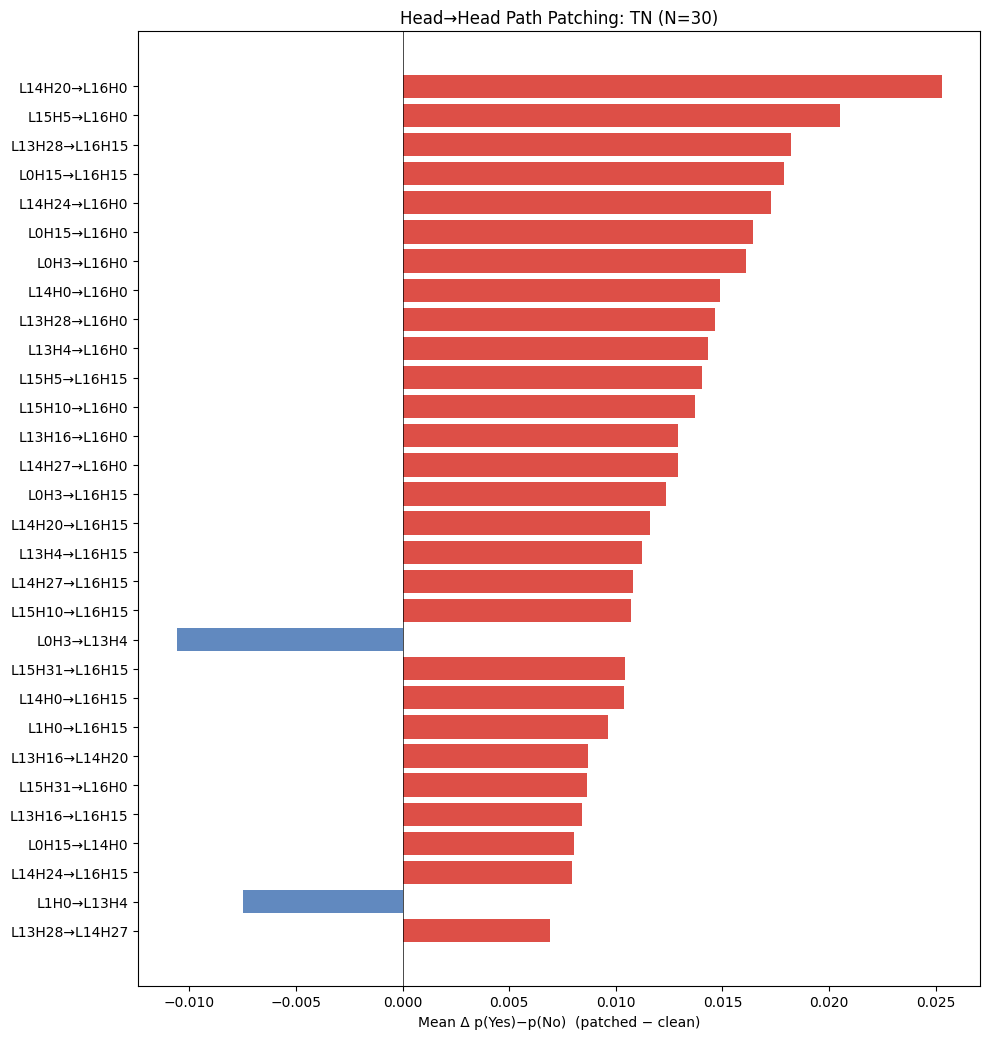

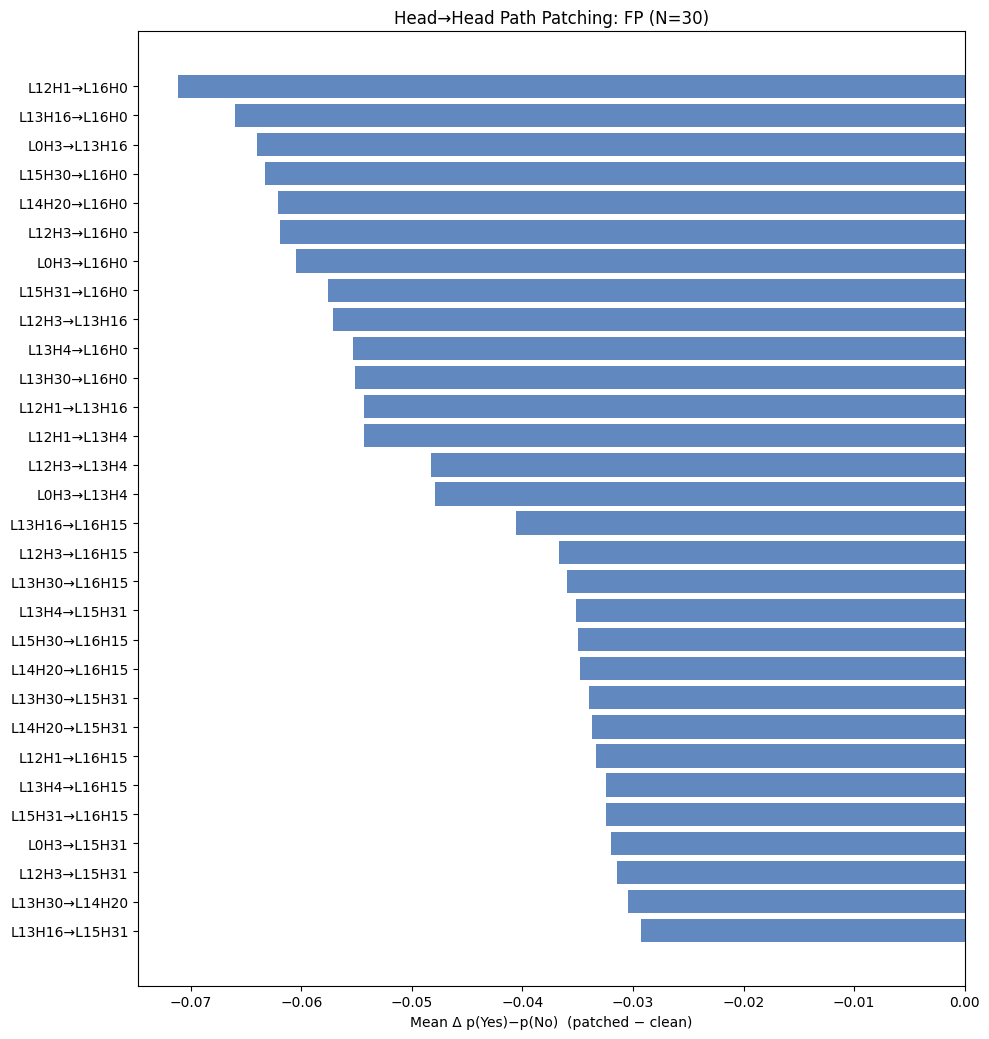

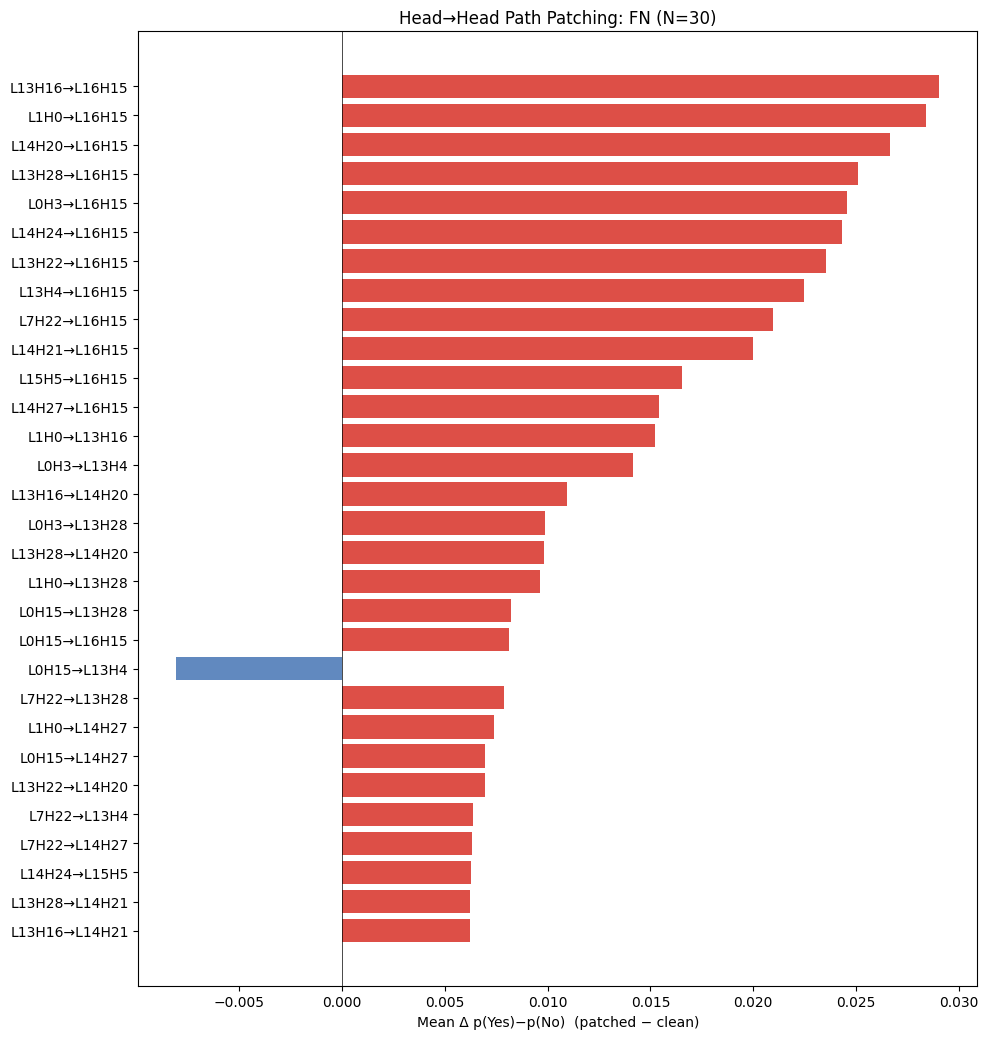


TOP EDGES PER CATEGORY (ranked by |mean delta|)

TP top-30 edges:
  1. L13H28 → L16H00  Δ=-0.0313 (→ no)
  2. L12H01 → L16H00  Δ=-0.0309 (→ no)
  3. L15H30 → L16H00  Δ=-0.0303 (→ no)
  4. L15H31 → L16H00  Δ=-0.0294 (→ no)
  5. L12H01 → L13H04  Δ=-0.0292 (→ no)
  6. L13H04 → L16H00  Δ=-0.0290 (→ no)
  7. L13H30 → L16H00  Δ=-0.0281 (→ no)
  8. L00H03 → L16H00  Δ=-0.0272 (→ no)
  9. L14H20 → L16H00  Δ=-0.0244 (→ no)
  10. L00H03 → L13H04  Δ=-0.0213 (→ no)
  11. L00H03 → L16H15  Δ=-0.0194 (→ no)
  12. L13H30 → L16H15  Δ=-0.0189 (→ no)
  13. L15H30 → L16H15  Δ=-0.0183 (→ no)
  14. L13H28 → L14H20  Δ=-0.0183 (→ no)
  15. L13H30 → L15H31  Δ=-0.0181 (→ no)
  16. L14H20 → L15H31  Δ=-0.0180 (→ no)
  17. L00H03 → L14H20  Δ=-0.0177 (→ no)
  18. L12H01 → L14H20  Δ=-0.0177 (→ no)
  19. L12H01 → L15H31  Δ=-0.0174 (→ no)
  20. L13H30 → L14H20  Δ=-0.0174 (→ no)
  21. L00H03 → L15H31  Δ=-0.0165 (→ no)
  22. L13H04 → L15H31  Δ=-0.0161 (→ no)
  23. L12H01 → L16H15  Δ=-0.0160 (→ no)
  24. L13H28 → L15H31 

In [21]:
for category in ["TP", "TN", "FP", "FN"]:
    if category in all_results and all_results[category]:
        plot_category_edges(all_results[category], category, n_show=30)


# ---- Cross-category comparison: same edges, different labels ----
# For each category, pick its top-3 strongest edges and show their means.

print("\n" + "=" * 60)
print("TOP EDGES PER CATEGORY (ranked by |mean delta|)")
print("=" * 60)

for category in ["TP", "TN", "FP", "FN"]:
    if category not in all_results:
        continue
    items = [(deltas.mean(), sl, sh, rl, rh)
             for (sl, sh, rl, rh), deltas in all_results[category].items()]
    items.sort(key=lambda x: -abs(x[0]))

    print(f"\n{category} top-30 edges:")
    for i, (mean_val, sl, sh, rl, rh) in enumerate(items[:30]):
        direction = "→ yes" if mean_val > 0 else "→ no"
        print(f"  {i+1}. L{sl:02d}H{sh:02d} → L{rl:02d}H{rh:02d}  "
              f"Δ={mean_val:+.4f} ({direction})")